In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
from numba import njit
from scipy.ndimage import rotate, shift

In [ ]:
def augment_dataset(X_flat, y_flat, num_new_samples=25000):
    print(f"Generating {num_new_samples} augmented EMNIST images. Please wait...")
    
    X_augmented = []
    y_augmented = []
    
    random_indices = np.random.choice(len(X_flat), num_new_samples, replace=False)
    
    for idx in random_indices:
        image = X_flat[idx]
        label = y_flat[idx]
        
        angle = np.random.uniform(-10, 10)
        img_rotated = rotate(image, angle, reshape=False, order=1, mode='nearest')
        
        shift_y = np.random.uniform(-2, 2)
        shift_x = np.random.uniform(-2, 2)
        img_shifted = shift(img_rotated, shift=(shift_y, shift_x), order=1, mode='nearest')
        
        img_final = np.clip(img_shifted, 0.0, 1.0)
        
        X_augmented.append(img_final)
        y_augmented.append(label)
        
    return np.array(X_augmented), np.array(y_augmented)

In [ ]:
print("Downloading MNIST... (This takes a few seconds)")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_raw = mnist.data
y_raw = mnist.target.astype(int)

X_processed = (X_raw.reshape(-1, 28, 28) / 255.0).astype(np.float32)

num_samples = y_raw.shape[0]
num_classes = 10  
y_one_hot = (np.zeros((num_samples, num_classes))).astype(np.float32)
y_one_hot[np.arange(num_samples), y_raw] = 1.0

X_train_flat, X_test_flat, y_train_flat, y_test_flat = train_test_split(
    X_processed, y_one_hot, test_size=0.2, random_state=42
)


X_aug, y_aug = augment_dataset(X_train_flat, y_train_flat, num_new_samples=25000)

X_train_massive = np.concatenate((X_train_flat, X_aug), axis=0)
y_train_massive = np.concatenate((y_train_flat, y_aug), axis=0)

shuffle_idx = np.random.permutation(len(X_train_massive))
X_train_massive = X_train_massive[shuffle_idx]
y_train_massive = y_train_massive[shuffle_idx]


def create_batches(X, y, batch_size):
    num_samples = X.shape[0]
    num_batches = num_samples // batch_size 

    X_truncated = X[:num_batches * batch_size]
    y_truncated = y[:num_batches * batch_size]
    
    # Reshape the lists to add the 'batch_size' dimension
    X_batched = X_truncated.reshape(num_batches, batch_size, 28, 28)
    y_batched = y_truncated.reshape(num_batches, batch_size, 10)
    
    return X_batched, y_batched

batch_size = 64

X_train, y_train = create_batches(X_train_massive, y_train_massive, batch_size)
X_test, y_test = create_batches(X_test_flat, y_test_flat, batch_size)

print("--- MNIST Data Ready ---")
print(f"X_train Batched Shape: {X_train.shape} -> (batches, batch_size, height, width)")
print(f"y_train Batched Shape: {y_train.shape} -> (batches, batch_size, target_nodes)")

In [ ]:
@njit(fastmath=True)
def convolution(image,kernel):
    n = image.shape[0] - kernel.shape[0] +1
    m = kernel.shape[0]

    r = np.zeros((n, n))

    for i in range(0,n):
        for j in range(0,n):
            s=0
            for l in range(i,i+m):
                for k in range(j,j+m):
                    s+= image[l][k]*kernel[l-i][k-j]
            
            r[i][j] = s
    
    return r

@njit(fastmath=True)
def maxPooling(image,window_size):
    n = int(image.shape[0]/window_size)
    m = int(window_size)
    k = int(image.shape[0])

    r = np.zeros((n, n))
    index = np.zeros((n * n, 2), dtype=np.int32)

    idx_counter = 0

    for i in range(0,k,m):
        for j in range(0,k,m):
            h=-99999
            idx_x=i
            idx_y=j
            for p in range(i,i+m):
                for q in range(j,j+m):
                    if(h<image[p][q]):
                        h=image[p][q]
                        idx_x=p
                        idx_y=q
        
            r[i//m][j//m] = h
            index[idx_counter][0] = idx_x
            index[idx_counter][1] = idx_y
            idx_counter += 1

    return r , index

def padding(image,p,position):
    if(p%2==0 and p!=0):
        n = image.shape[0]
        n_new = n+2
        r = [0]*n_new

        for i in range(0,n):
            r.append(0)
            for j in range(0,n):
                r.append(image[i][j])
            r.append(0)

        r1 = [0]*n_new
        r.extend(r1)
        r = np.array(r)
        image_new = r.reshape(n_new,n_new)

        return padding(image_new,p-2,position)
    elif(p%2==1):
        return single_padding(image,p,position)
    else:
        return image


def single_padding(image,p,position):
    if(p>=1 and p%2==1):
        n = image.shape[0]
        n_new = n+1
        if(position=="right"):
            r = [0]*n_new
        else:
            r=[]

        for i in range(0,n):
            if(position=="left"):
                r.append(0)
            for j in range(0,n):
                r.append(image[i][j])
            if(position=="right"):
               r.append(0)
        
        if(position=="left"):
            r1 = [0]*n_new
            r.extend(r1)
        r = np.array(r)
        image_new = r.reshape(n_new,n_new)

        return padding(image_new,p-1,position)
    else:
        return image
    
def tanh(n):
    return np.tanh(n)

def dtanh(n):
    return 1-(np.tanh(n)**2)

def relu(n):
    return np.maximum(0, n)

def drelu(n):
    return np.where(n > 0, 1.0, 0.0)

def sigmoid(n):
    n = np.clip(n, -500, 500) 
    return 1.0 / (1.0 + np.exp(-n))

def dsoftmax(val,probs):
    val = np.exp(val)
    p = val/np.sum(probs)

    return p-p**2
    

In [ ]:
def mat(row,col):
    rng = np.random.default_rng()
    if(row!=1):
        normal_mat = rng.standard_normal((row,col))* np.sqrt(2.0 / row)
    else:
        normal_mat = rng.standard_normal(col)*0.01
    return normal_mat

def relu(z):
    return np.maximum(0,z)

def softmax(predicted):
    predicted = np.array(predicted)
    predicted = predicted - np.max(predicted, axis=-1, keepdims=True) 
    predicted = np.exp(predicted)
    m = np.sum(predicted, axis=-1, keepdims=True)
    prob = predicted / m
    return prob

def ANN(image,nodes):
    W = []
    X = []
    B = []
    Z = []
    n = len(nodes)

    x=image
    w=[]
    b=[]
    z=[]
    for i in range(1,n):
        if(i!=1):
            x=relu(z)
        w=mat(len(x[0]),nodes[i])
        b=mat(1,nodes[i])
        z=np.dot(x,w) + b

        X.append(x)
        W.append(w)
        B.append(b)
        Z.append(z)

    return X , W , B , Z

def ANNforwardprop(images,nodes,X,W,B,Z,y_target):
    X[0] = np.array(images)
    
    for i in range(1,len(nodes)):
        if(i!=1):
            X[i-1]=relu(Z[i-2])
        Z[i-1] = np.dot(X[i-1],W[i-1]) + B[i-1]

    Y = softmax(Z[-1])
    l = loss(Y,y_target)
    return Z[-1] , l


def drelu(n):
    return (n > 0).astype(float)


def ANNbackprop(a,y_target,nodes,X,W,B,Z):
    Y = softmax(Z[-1])
    dldx = Y-y_target
    dldz=0
    dldb=0
    dldw=0
    for i in range(len(nodes)-2,-1,-1):
        if(i!=len(nodes)-2):
            dldz = dldx*drelu(Z[i])
        else:
            dldz = dldx

        lambd = 0.005

        dldb = np.sum(dldz, axis=0)
        dldw = np.dot(X[i].T, dldz)
        dldx = np.dot(dldz,W[i].T)
        B[i] -= a*dldb
        W[i] -= a * (dldw + (lambd * W[i]))
    
    return dldx

        
def loss(Y,y_target):
    epsilon = 1e-15
    Y_clipped = np.clip(Y,epsilon,1-epsilon)
    l = -np.sum(y_target*np.log(Y_clipped))
    return l

def predict(z):
    y = softmax(z)
    m = np.argmax(y, axis=-1)
    return m

In [ ]:
def train(nodes,a,X,W,B,Z,X_train,y_train,goal):
    L=0
    correct=0
    for i in range(0,len(X_train)):
        z , l = ANNforwardprop(X_train[i],nodes,X,W,B,Z,y_train[i])
        L+=l
        if(goal=="train"):
            ANNbackprop(a,y_train[i],nodes,X,W,B,Z)
        else:
            p = predict(z)
            targets = np.argmax(y_train[i], axis=-1)
            correct += np.sum(p == targets)
    
    if(goal=="train"):
        return L , correct
    else:
        return correct

In [ ]:
a=0.002
def multiconvolution(images,kernel):
    multi_trns = [convolution(images[i],kernel) for i in range(0,len(images))]
    return multi_trns

def createKernels(size,number):
    kernels = np.random.randn(number,size,size)*0.01
    return kernels

def poolReLUConvo(image,kernels,size):
    pooled_images = []
    pooled_images_idx = []
    for i in range(0,len(kernels)):
        r,index=maxPooling(np.maximum(0,convolution(image,kernels[i])),size)
        pooled_images.append(r)
        pooled_images_idx.append(index)
    return pooled_images , pooled_images_idx

def multipoolReLUConvo(images,kernels,size):
    all_pooled_img , all_pooled_idx = map(list,zip(*(poolReLUConvo(img,kernels,size) for img in images)))
    return all_pooled_img , all_pooled_idx

def flatning(images):
    return np.array(images).flatten(), len(images)

def multiflatning(imagess):
    fl , l = map(list,zip(*(flatning(imgs) for imgs in imagess)))
    return fl , l
    

def ANNtoCNN(dldx_input,pooled_images_shape):
    batch_size = len(dldx_input)
    num_kernels = len(pooled_images_shape[0])
    grid_size = len(pooled_images_shape[0][0])
    r = dldx_input.reshape(batch_size,num_kernels, grid_size, grid_size)
    return r

@njit(fastmath=True)
def errMatrix(dEdY,index_arr,kernel_size,image_size):
    ny = image_size-kernel_size+1
    n = dEdY.shape[0]
    E = np.zeros((ny,ny))
    k=0

    for i in range(0,n):
        for j in range(0,n):
            E[index_arr[k][0]][index_arr[k][1]]=dEdY[i][j]
            k+=1
    
    return E

@njit(fastmath=True)
def multierrMatrix(dEdYs,index_arrs,kernel_size,image_size):
    E = []

    for i in range(0,len(dEdYs)):
        E.append(errMatrix(dEdYs[i],index_arrs[i],kernel_size,image_size))
    
    return E

def updateKernel(kernel,errorMatrix,image,a):
    dEdK = convolution(image,errorMatrix)
    kernel -= a*dEdK

def multiupdateKernel(kernel,errorMatrixs,images,a):
    for i in range(0,len(errorMatrixs)):
        updateKernel(kernel,errorMatrixs[i],images[i],a)


def trainCNN(kernels,kernel_size,pool_mat_size,no_nodes,X_train,y_train,goal,X,W,B,Z):

    predicted = []
    total_epoch_loss=0
    for j in range(0,len(X_train)):
        all_pooled_img , all_pooled_img_idx = multipoolReLUConvo(X_train[j],kernels,pool_mat_size)
        all_flattened_arr , all_f_n = multiflatning(all_pooled_img)

        if(goal=='train'):
            pred , l = ANNforwardprop(all_flattened_arr,no_nodes,X,W,B,Z,y_train[j])
            probs = softmax(pred)
            total_epoch_loss += loss(probs,y_train[j])

            dldx_input = ANNbackprop(a, y_train[j], no_nodes, X, W, B, Z)

            dPE = ANNtoCNN(dldx_input,all_pooled_img)
            EM=[]
            for i in range(0,len(dPE)):
                EM.append(multierrMatrix(dPE[i],all_pooled_img_idx[i],kernel_size,len(X_train[j][0])))

            EM_by_kernel = []
            for k in range(len(kernels)):
                kernel_errors = [EM[img_idx][k] for img_idx in range(len(X_train[j]))]
                EM_by_kernel.append(kernel_errors)

            for l in range(0,len(kernels)):
                multiupdateKernel(kernels[l],EM_by_kernel[l],X_train[j],a)
        else:
            pred , l = ANNforwardprop(all_flattened_arr,no_nodes,X,W,B,Z,y_train[j])
            probs = softmax(pred)
            predicted.append(np.argmax(probs,axis=-1))

    if goal == 'train':
        avg_loss = total_epoch_loss / len(X_train)
        return avg_loss
    else:
        return predicted 


In [ ]:

epochs = 20
kernels = createKernels(3, 16)
no_nodes = [2704, 128, 64, 10]
dummy_flattened_batch = np.zeros((64,2704))
X, W, B, Z = ANN(dummy_flattened_batch, no_nodes)


In [ ]:
initial_lr = 0.003
decay_rate = 0.85

print("Starting CNN Batch Training...")
for i in range(0, epochs):

    a = initial_lr * (decay_rate ** i)

    shuffled_indices = np.random.permutation(len(X_train))
    
    X_train_shuffled = X_train[shuffled_indices]
    y_train_shuffled = y_train[shuffled_indices]

    avg_loss = trainCNN(kernels, 3, 2, no_nodes, X_train_shuffled, y_train_shuffled, "train", X, W, B, Z)
    print(f"Epoch {i+1}/{epochs} | Loss: {avg_loss:.4f}")

print("\n--- Evaluating Test Set ---")
predicted_test = trainCNN(kernels, 3, 2, no_nodes, X_test, y_test, "test", X, W, B, Z)

true_labels_test = np.argmax(y_test, axis=-1) 
predicted_test = np.array(predicted_test)

correct_predictions_test = np.sum(predicted_test == true_labels_test)
total_test_images = true_labels_test.size 
accuracy_test = (correct_predictions_test / total_test_images) * 100

print(f"Total Correct: {correct_predictions_test} / {total_test_images}")
print(f"Testing Accuracy: {accuracy_test:.2f}%")


print("\n--- Evaluating Training Set ---")
predicted_train = trainCNN(kernels, 3, 2, no_nodes, X_train, y_train, "test", X, W, B, Z)

true_labels_train = np.argmax(y_train, axis=-1)
predicted_train = np.array(predicted_train)

correct_predictions_train = np.sum(predicted_train == true_labels_train)
total_train_images = true_labels_train.size
accuracy_train = (correct_predictions_train / total_train_images) * 100

print(f"Total Correct: {correct_predictions_train} / {total_train_images}")
print(f"Training Accuracy: {accuracy_train:.2f}%")

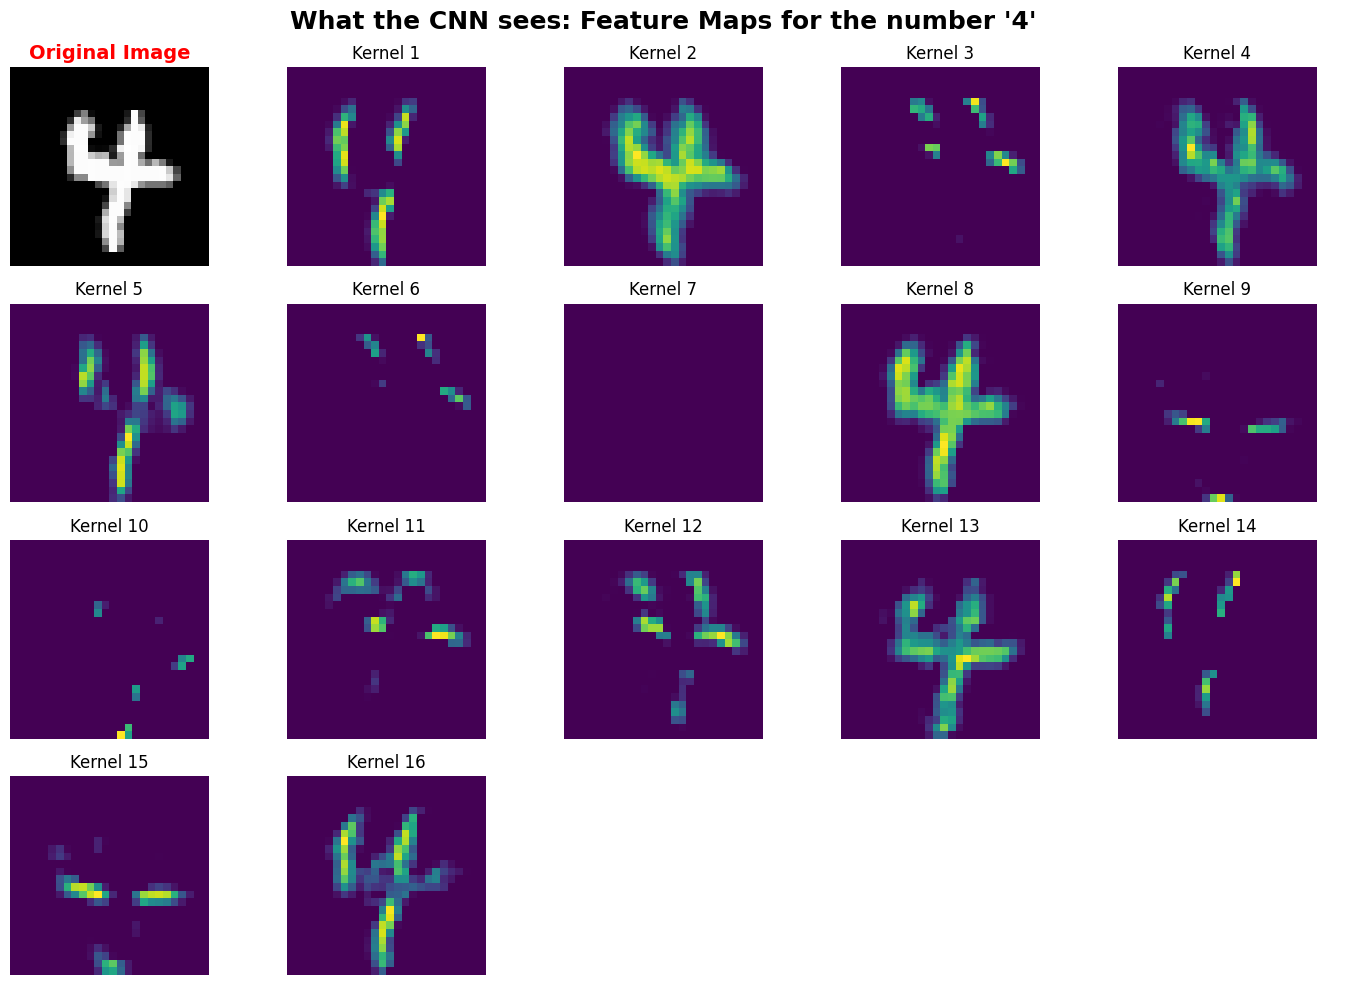

In [106]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_feature_maps(target_digit, X_data, y_data, trained_kernels):
    # 1. Convert one-hot labels back to normal numbers (0-9)
    labels = np.argmax(y_data, axis=-1)
    
    # 2. Find the first image in the dataset that matches your target digit
    valid_indices = np.where(labels == target_digit)[0]
    if len(valid_indices) == 0:
        print(f"Digit {target_digit} not found!")
        return
        
    chosen_index = valid_indices[0]
    original_image = X_data[chosen_index]
    
    # 3. Create a nice 4x5 plotting grid
    fig, axes = plt.subplots(4, 5, figsize=(14, 10))
    fig.suptitle(f"What the CNN sees: Feature Maps for the number '{target_digit}'", fontsize=18, fontweight='bold')
    
    # Hide all axis ticks for a clean look
    for ax in axes.flat:
        ax.axis('off')
        
    # 4. Plot the Original Image in the top left
    axes[0, 0].imshow(original_image, cmap='gray')
    axes[0, 0].set_title("Original Image", color='red', fontsize=14, fontweight='bold')
    
    # 5. Run the image through all 16 kernels and plot the results
    plot_idx = 1
    for i in range(16):
        row = plot_idx // 5
        col = plot_idx % 5
        
        # Apply your exact Math: Convolution + ReLU
        convo_output = convolution(original_image, trained_kernels[i])
        relu_output = np.maximum(0, convo_output)
        
        # We use the 'viridis' color map because it makes activations pop!
        # Bright yellow = Strong activation (The kernel found what it was looking for)
        # Dark purple = Zero activation (ReLU turned it off)
        axes[row, col].imshow(relu_output, cmap='viridis')
        axes[row, col].set_title(f"Kernel {i+1}")
        
        plot_idx += 1
        
    plt.tight_layout()
    plt.show()

# ==========================================
# --- CHOOSE YOUR DIGIT HERE ---
# ==========================================
# Change this number to 0, 1, 2, 3, etc. to see how the network views different shapes!
digit_to_look_at = 4

visualize_feature_maps(digit_to_look_at, X_test_flat, y_test_flat, kernels)